C:\Users\dario\AppData\Local\Temp\ipykernel_8628\581870866.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(15), palette='viridis')


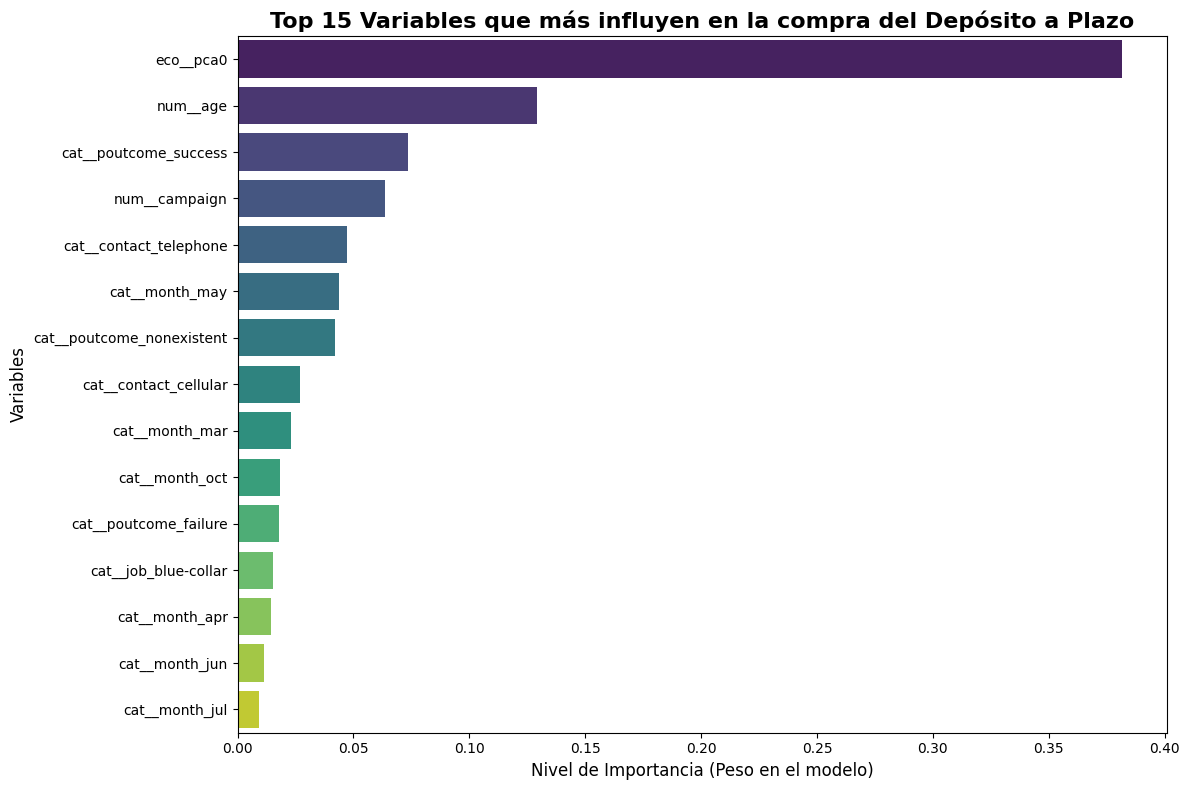


--- TOP 5 VARIABLES MÁS IMPORTANTES (En números) ---
                  Variable  Importancia
28               eco__pca0     0.381731
0                 num__age     0.129085
27   cat__poutcome_success     0.073486
1            num__campaign     0.063682
14  cat__contact_telephone     0.047121


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from preprocessing import preparar_todo_el_dataset


X_train_procesado, X_test_procesado, y_train, y_test, df_limpio, X_train, X_test, pipeline = preparar_todo_el_dataset()

# modelo optimizado
mejor_modelo = joblib.load('models/random_forest_optimizado.joblib')

# 0btener los nombres de las variables
try:
    
    nombres_variables = pipeline.get_feature_names_out()
except:
    
    nombres_variables = X_train_procesado.columns

# Extraer  "Feature Importance" directamente del Random Forest
importancias = mejor_modelo.feature_importances_

# DataFrame ordenando de la más importante a la menos importante
df_importancias = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# GRAFICAR  15 DE VARIABLES
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(15), palette='viridis')

plt.title('Top 15 Variables que más influyen en la compra del Depósito a Plazo', fontsize=16, fontweight='bold')
plt.xlabel('Nivel de Importancia (Peso en el modelo)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()


plt.show()


print("\n--- TOP 5 VARIABLES MÁS IMPORTANTES (En números) ---")
print(df_importancias.head(5))

¿Qué impulsa a un cliente a comprar?

Tras analizar la importancia de las variables (Feature Importance) del modelo Random Forest Optimizado, hemos descubierto insights vitales para la estrategia del banco. Los valores representan el peso porcentual que el modelo le asigna a cada variable para tomar su decisión final:

1. El contexto macroeconómico es el rey (38.1%):La variable `eco__pca0` (que agrupa indicadores como el Euribor, la inflación y el empleo) dicta casi el 40% de la decisión del cliente. Recomendación: El banco no debe gastar el mismo presupuesto en call centers todo el año. Las campañas de Depósitos a Plazo deben lanzarse agresivamente solo cuando los indicadores macroeconómicos (especialmente las tasas de interés) sean favorables para el ahorro. Si el contexto es malo, las llamadas serán un desperdicio de dinero.

2. La edad es un factor determinante (12.9%):
   La edad de la persona (`num__age`) es el segundo factor más importante. Recomendación: En lugar de llamar a la base de datos al azar, el banco debe perfilar las llamadas hacia los segmentos de edad que históricamente tienen mayor liquidez y cultura de ahorro (usualmente adultos mayores o profesionales consolidados).

3. Fidelidad y éxito previo (7.3%):
   El hecho de que un cliente haya aceptado una campaña en el pasado (`poutcome_success`) es un fuerte predictor de éxito futuro. Recomendación: Estos clientes son "leales". Deberían ser siempre los primeros en ser contactados en cualquier campaña nueva, requiriendo menos esfuerzo de venta.

4. El riesgo de la insistencia (`num__campaign` con 6.3%):
   El número de contactos realizados durante la campaña actual tiene un peso significativo. Esto demuestra que la respuesta del cliente se ve fuertemente afectada por la insistencia. Recomendación: El banco debe establecer un límite máximo de llamadas por cliente para evitar la fatiga y el rechazo automático (de 3 a 4 maximo).

El modelo ha demostrado que predecir la suscripción a un depósito a plazo es más un problema de "momento económico" (timing) que de simples habilidades de venta. Utilizando este modelo para filtrar la base de datos antes de llamar, el banco puede aumentar su tasa de conversión y reducir drásticamente los costos operativos del Call Center.

 Métrica ROC AUC (Capacidad de Discriminación)

Para complementar el análisis del F1-Score (0.48), evaluamos el modelo final utilizando la métrica ROC AUC (Área bajo la curva ROC), obteniendo un resultado de 0.802. 

¿Qué significa este 0.802 en la práctica?
* Poder de ordenamiento: El ROC AUC no mide si el modelo acierta un "Sí" o un "No" absoluto, sino qué tan bien ordena a los clientes según su probabilidad de compra. 
* Un valor de 0.50 significaría que el modelo tiene el mismo éxito que lanzar una moneda al aire (azar absoluto). Un valor de 1.00 sería un modelo perfecto que predice el futuro con total certeza.
* Nuestro resultado de 0.802 se clasifica técnicamente como un modelo con excelente capacidad de discriminación. Significa que si seleccionamos al azar a un cliente que sí va a comprar el depósito y a otro que no, existe un 80.2% de probabilidad de que el modelo le asigne una puntuación de interés más alta al comprador real.

Impacto Estratégico
Este 80% de efectividad para separar perfiles le permite al banco priorizar su lista de llamadas. En lugar de contactar a los clientes de forma aleatoria, el call center puede empezar llamando estrictamente desde el tope de la lista (los clientes con mayor probabilidad según el modelo), asegurando capturar la gran mayoría de las ventas en las primeras horas de la campaña y reduciendo drásticamente el costo operativo.